In [ ]:
!pip install --upgrade nltk

In [ ]:
df

,Waktu Posting,Text,Tanggal,Bulan,Tahun,sentimen
0,2025-11-16 12:19:15+07:00,enggak usah macem-macem lah kalau enggak paham...,16,11,2025,positif
1,2025-11-12 18:22:51+07:00,Biar gada lagi oknum2 bikin kosmetik skincare ...,12,11,2025,netral
2,2025-11-06 12:59:06+07:00,Slalu update product makeup/skincare dari BPOM...,6,11,2025,netral
3,2025-11-05 12:20:04+07:00,untung deh gw belum beli skincare &amp; make u...,5,11,2025,netral
4,2025-10-28 16:31:58+07:00,Sebelum beli kosmetik pastikan Pilih kosmetik ...,28,10,2025,netral
...,...,...,...,...,...,...
567,2025-11-07 09:29:50+07:00,ya ampun korban pink flash ngeri bgt untung ga...,7,11,2025,netral
568,2025-11-07 08:21:12+07:00,gila banyak bgt korbannya pink flash,7,11,2025,netral
569,2025-11-07 08:08:41+07:00,@strsshdp @ywonnielvs Pink flash lagi di tarik...,7,11,2025,netral
570,2025-11-07 02:29:47+07:00,Pink flash blm BPOM jifrrr fak,7,11,2025,netral


In [ ]:
df.to_excel('sentimen tweet_kosmetik.xlsx', index=False)

In [ ]:
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 8.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import pandas as dataframe
import string
import nltk
import matplotlib as mpl
import matplotlib.pyplot as plt
import re
import collections
import sys
import os
import numpy
import seaborn as sns
import csv
from collections import OrderedDict
from nltk.tokenize import word_tokenize
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from IPython.display import display
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
from pylab import figure, axes, pie, title, show
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
import nltk
nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
import pandas as pd

df = pd.read_excel('/content/tweet kosmetik (1).xlsx', sheet_name='Sheet2')
df

,created_at,full_text,tweet_url
0,Sun Nov 16 05:19:15 +0000 2025,enggak usah macem-macem lah kalau enggak paham...,https://x.com/undefined/status/198992621422474...
1,Wed Nov 12 11:22:51 +0000 2025,Biar gada lagi oknum2 bikin kosmetik skincare ...,https://x.com/undefined/status/198856816519066...
2,Thu Nov 06 05:59:06 +0000 2025,Slalu update product makeup/skincare dari BPOM...,https://x.com/undefined/status/198631236694724...
3,Wed Nov 05 05:20:04 +0000 2025,untung deh gw belum beli skincare &amp; make u...,https://x.com/undefined/status/198594015581612...
4,Tue Oct 28 09:31:58 +0000 2025,Sebelum beli kosmetik pastikan Pilih kosmetik ...,https://x.com/undefined/status/198310444475054...
...,...,...,...
567,Fri Nov 07 02:29:50 +0000 2025,ya ampun korban pink flash ngeri bgt untung ga...,https://x.com/undefined/status/198662209013770...
568,Fri Nov 07 01:21:12 +0000 2025,gila banyak bgt korbannya pink flash,https://x.com/undefined/status/198660481770868...
569,Fri Nov 07 01:08:41 +0000 2025,@strsshdp @ywonnielvs Pink flash lagi di tarik...,https://x.com/undefined/status/198660166679652...
570,Thu Nov 06 19:29:47 +0000 2025,Pink flash blm BPOM jifrrr fak,https://x.com/undefined/status/198651637910176...


In [ ]:
df = df.rename(columns={'created_at': 'Waktu Posting',
                        'full_text': 'Text'})
df.head()

,Waktu Posting,Text,tweet_url
0,Sun Nov 16 05:19:15 +0000 2025,enggak usah macem-macem lah kalau enggak paham...,https://x.com/undefined/status/198992621422474...
1,Wed Nov 12 11:22:51 +0000 2025,Biar gada lagi oknum2 bikin kosmetik skincare ...,https://x.com/undefined/status/198856816519066...
2,Thu Nov 06 05:59:06 +0000 2025,Slalu update product makeup/skincare dari BPOM...,https://x.com/undefined/status/198631236694724...
3,Wed Nov 05 05:20:04 +0000 2025,untung deh gw belum beli skincare &amp; make u...,https://x.com/undefined/status/198594015581612...
4,Tue Oct 28 09:31:58 +0000 2025,Sebelum beli kosmetik pastikan Pilih kosmetik ...,https://x.com/undefined/status/198310444475054...


In [ ]:
df = df.drop(columns=['Waktu Posting'])

In [ ]:
df = df.drop(columns=['tweet_url'])

In [ ]:
df

,Waktu Posting,Text
0,Sun Nov 16 05:19:15 +0000 2025,enggak usah macem-macem lah kalau enggak paham...
1,Wed Nov 12 11:22:51 +0000 2025,Biar gada lagi oknum2 bikin kosmetik skincare ...
2,Thu Nov 06 05:59:06 +0000 2025,Slalu update product makeup/skincare dari BPOM...
3,Wed Nov 05 05:20:04 +0000 2025,untung deh gw belum beli skincare &amp; make u...
4,Tue Oct 28 09:31:58 +0000 2025,Sebelum beli kosmetik pastikan Pilih kosmetik ...
...,...,...
567,Fri Nov 07 02:29:50 +0000 2025,ya ampun korban pink flash ngeri bgt untung ga...
568,Fri Nov 07 01:21:12 +0000 2025,gila banyak bgt korbannya pink flash
569,Fri Nov 07 01:08:41 +0000 2025,@strsshdp @ywonnielvs Pink flash lagi di tarik...
570,Thu Nov 06 19:29:47 +0000 2025,Pink flash blm BPOM jifrrr fak


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Waktu Posting  572 non-null    object
 1   Text           572 non-null    object
dtypes: object(2)
memory usage: 9.1+ KB


In [ ]:
df['Waktu Posting'] = pd.to_datetime(df['Waktu Posting'])
df['Waktu Posting'] = df['Waktu Posting'].dt.tz_convert('Asia/Jakarta')

/tmp/ipython-input-1620712132.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Waktu Posting'] = pd.to_datetime(df['Waktu Posting'])


In [ ]:
df['Waktu Posting'].dtype

datetime64[ns, Asia/Jakarta]

In [ ]:
df

,Waktu Posting,Text
0,2025-11-16 12:19:15+07:00,enggak usah macem-macem lah kalau enggak paham...
1,2025-11-12 18:22:51+07:00,Biar gada lagi oknum2 bikin kosmetik skincare ...
2,2025-11-06 12:59:06+07:00,Slalu update product makeup/skincare dari BPOM...
3,2025-11-05 12:20:04+07:00,untung deh gw belum beli skincare &amp; make u...
4,2025-10-28 16:31:58+07:00,Sebelum beli kosmetik pastikan Pilih kosmetik ...
...,...,...
567,2025-11-07 09:29:50+07:00,ya ampun korban pink flash ngeri bgt untung ga...
568,2025-11-07 08:21:12+07:00,gila banyak bgt korbannya pink flash
569,2025-11-07 08:08:41+07:00,@strsshdp @ywonnielvs Pink flash lagi di tarik...
570,2025-11-07 02:29:47+07:00,Pink flash blm BPOM jifrrr fak


In [ ]:
df['Tanggal'] = df['Waktu Posting'].dt.day
df['Bulan'] = df['Waktu Posting'].dt.month
df['Tahun'] = df['Waktu Posting'].dt.year

In [ ]:
df

,Waktu Posting,Text,Tanggal,Bulan,Tahun
0,2025-11-16 12:19:15+07:00,enggak usah macem-macem lah kalau enggak paham...,16,11,2025
1,2025-11-12 18:22:51+07:00,Biar gada lagi oknum2 bikin kosmetik skincare ...,12,11,2025
2,2025-11-06 12:59:06+07:00,Slalu update product makeup/skincare dari BPOM...,6,11,2025
3,2025-11-05 12:20:04+07:00,untung deh gw belum beli skincare &amp; make u...,5,11,2025
4,2025-10-28 16:31:58+07:00,Sebelum beli kosmetik pastikan Pilih kosmetik ...,28,10,2025
...,...,...,...,...,...
567,2025-11-07 09:29:50+07:00,ya ampun korban pink flash ngeri bgt untung ga...,7,11,2025
568,2025-11-07 08:21:12+07:00,gila banyak bgt korbannya pink flash,7,11,2025
569,2025-11-07 08:08:41+07:00,@strsshdp @ywonnielvs Pink flash lagi di tarik...,7,11,2025
570,2025-11-07 02:29:47+07:00,Pink flash blm BPOM jifrrr fak,7,11,2025


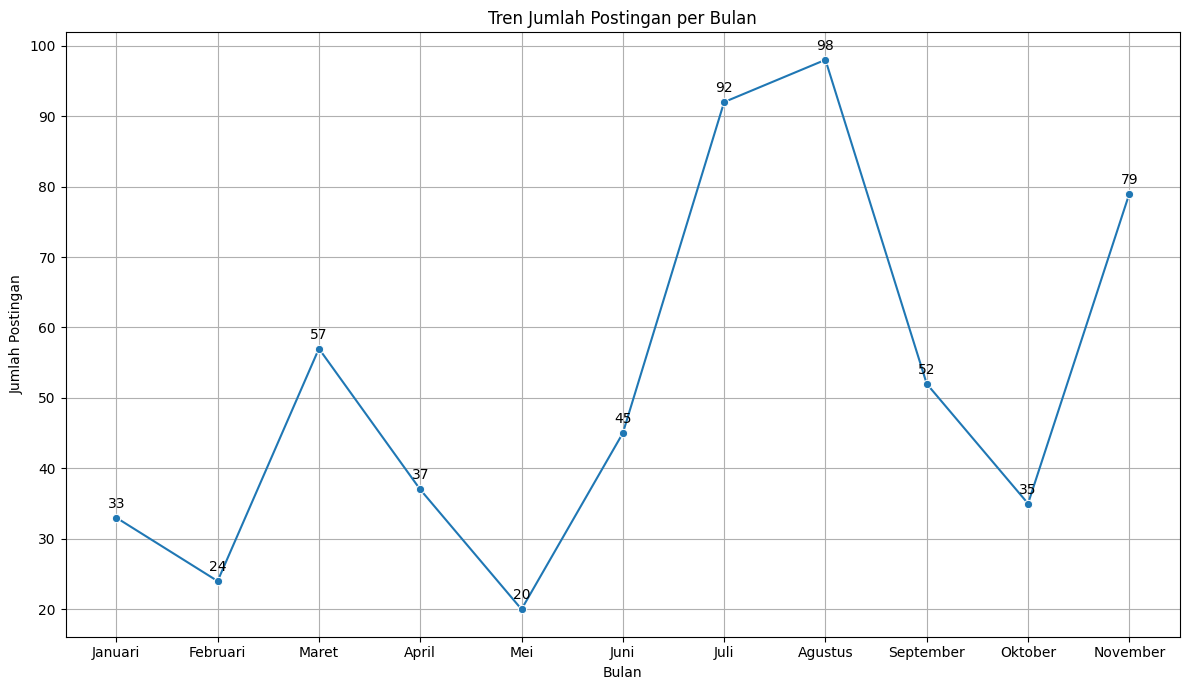

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

posts_per_month = df['Bulan'].value_counts().sort_index().reset_index()
posts_per_month.columns = ['Bulan', 'Jumlah Postingan']

month_names = {
    1: 'Januari', 2: 'Februari', 3: 'Maret', 4: 'April', 5: 'Mei', 6: 'Juni',
    7: 'Juli', 8: 'Agustus', 9: 'September', 10: 'Oktober', 11: 'November', 12: 'Desember'
}
posts_per_month['Nama Bulan'] = posts_per_month['Bulan'].map(month_names)

plt.figure(figsize=(12, 7))
sns.lineplot(x='Nama Bulan', y='Jumlah Postingan', data=posts_per_month, marker='o')

for x, y in zip(posts_per_month['Nama Bulan'], posts_per_month['Jumlah Postingan']):
    plt.text(x, y + 1, str(y), ha='center', va='bottom')

plt.title('Tren Jumlah Postingan per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Postingan')
plt.grid(True)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
pre_text = df['Text']
pre_text

,Text
0,enggak usah macem-macem lah kalau enggak paham...
1,Biar gada lagi oknum2 bikin kosmetik skincare ...
2,Slalu update product makeup/skincare dari BPOM...
3,untung deh gw belum beli skincare &amp; make u...
4,Sebelum beli kosmetik pastikan Pilih kosmetik ...
...,...
567,ya ampun korban pink flash ngeri bgt untung ga...
568,gila banyak bgt korbannya pink flash
569,@strsshdp @ywonnielvs Pink flash lagi di tarik...
570,Pink flash blm BPOM jifrrr fak


In [ ]:
import re

# Proses pembersihan teks
dataclean = []
for line in pre_text:
    line = re.sub(r"http\S+", " ", line)            # Menghapus link
    line = re.sub(r"@\S+", " ", line)               # Menghapus username
    line = re.sub(r"#\S+", " ", line)               # Menghapus hashtag
    line = re.sub(r"\d", " ", line)                 # Menghapus angka
    line = re.sub(r"<.*?>", " ", line)              # Menghapus emotikon/HTML tag
    line = re.sub(r"\n", " ", line)                 # Menghapus baris baru
    line = re.sub(r",", " ", line)                  # Menghapus koma
    line = re.sub(r"[^\w\s]", " ", line)            # Menghapus tanda baca
    line = re.sub(r"\s+", " ", line).strip()        # Menghapus spasi berlebih
    dataclean.append(line)

In [ ]:
# Membuat DataFrame perbandingan
datahapus = pd.DataFrame({
    'Sebelum Cleaning': pre_text,
    'Sesudah Cleaning': dataclean
})

# Menampilkan DataFrame
datahapus.tail()

,Sebelum Cleaning,Sesudah Cleaning
567,ya ampun korban pink flash ngeri bgt untung ga...,ya ampun korban pink flash ngeri bgt untung ga...
568,gila banyak bgt korbannya pink flash,gila banyak bgt korbannya pink flash
569,@strsshdp @ywonnielvs Pink flash lagi di tarik...,Pink flash lagi di tarik dari edaran kaa tiati...
570,Pink flash blm BPOM jifrrr fak,Pink flash blm BPOM jifrrr fak
571,ngeri bgtt jir liat korban yg pake pink flash,ngeri bgtt jir liat korban yg pake pink flash


In [ ]:
def cek_ngegas(teks):
    kapital = re.findall(r"[A-Z]", teks)
    return len(kapital) >= 30

kalimat_ngegas = [kalimat for kalimat in dataclean if cek_ngegas(kalimat)]

for kalimat in kalimat_ngegas:
    print(kalimat)

BELI SKINCARE JANGAN CUMA MURAH Kelihatan praktis dan murah tapi risikonya besar Kosmetik share in jar tidak memiliki izin edar BPOM tidak terjamin higienitasnya dan bisa aja isinya diganti produk lain yang berbahaya
BPOM UNGKAP KOSMETIK BERBAHAYA Hai lagi dan lagi BPOM menemukan produk Baca informasi selengkapnya di siaran pers BPOM pada tautan berikut
BPOM UNGKAP KOSMETIK BERBAHAYA Hai lagi dan lagi BPOM menemukan produk kosmetik yang mengandung bahan berbahaya dilarang Hasil temuan ini berasal dari pengawasan intensif yang dilakukan pada periode Juli sampai dengan September
BPOM UNGKAP KOSMETIK BERBAHAYA Hai Baca informasi selengkapnya di siaran pers BPOM pada tautan berikut
Reposted from BPOM UNGKAP KOSMETIK BERBAHAYA Hai lagi dan lagi BPOM menemukan produk kosmetik yang mengandung bahan berbahaya dilarang Hasil temuan ini berasal dari pengawasan intensif yang dilakukan pada periode Juli sampai dengan September
Tapi hati hati Efek instan itu SANGAT mungkin disebabkan oleh bahan kim

In [ ]:
kata = {
    "g ": "tidak ",
    "ga ": "tidak ",
    "gak ": "tidak ",
    "nggak ": "tidak ",
    "ngga ": "tidak ",
    "enggak ": "tidak ",
    "engga ": "tidak ",
    "gk ": "tidak ",
    "gx ": "tidak ",
    "tdk ": "tidak ",
    "tak ": "tidak ",
    "kagak ": "tidak ",
    "ora ": "tidak ",
    "ndak ": "tidak ",
    "g ": "tidak ",
    "jgn ": "jangan ",
    "jngn ": "jangan ",
    "gw ": "saya ",
    "gue ": "saya ",
    "gua ": "saya ",
    "aq ": "saya ",
    "aku ": "saya ",
    "sy ": "saya ",
    "sya ": "saya ",
    "lu ": "kamu ",
    "loe ": "kamu ",
    "lo ": "kamu ",
    "elu ": "kamu ",
    "km ": "kamu ",
    "kmu ": "kamu ",
    "kak ": "kakak ",
    "kaka ": "kakak ",
    "sis ": "kakak ",
    "bro ": "kakak ",
    "gan ": "kakak ",
    "min ": "admin ",
    "guys ": "teman ",
    "guysss ": "teman ",
    "guysnya ": "teman ",
    "guysssnya ": "teman ",
    "yg ": "yang ",
    "yg. ": "yang ",
    "yng ": "yang ",
    "dgn ": "dengan ",
    "dg ": "dengan ",
    "dngn ": "dengan ",
    "dr ": "dari ",
    "dri ": "dari ",
    "utk ": "untuk ",
    "bwt ": "buat ",
    "buat ": "untuk ",
    "buatnya ": "untuk ",
    "u/ ": "untuk ",
    "u ": "untuk ",
    "krn ": "karena ",
    "karna ": "karena ",
    "krna ": "karena ",
    "soalnya ": "karena ",
    "klo ": "kalau ",
    "kl ": "kalau ",
    "kalo ": "kalau ",
    "kalok ": "kalau ",
    "tp ": "tapi ",
    "tpi ": "tapi ",
    "tapii ": "tapi ",
    "namun ": "tapi ",
    "aja ": "saja ",
    "aj ": "saja ",
    "doang ": "saja ",
    "jg ": "juga ",
    "jga ": "juga ",
    "juga ": "juga ",
    "trs ": "terus ",
    "trus ": "terus ",
    "trusss ": "terus ",
    "teross ": "terus ",
    "sm ": "sama ",
    "sama ": "sama ",
    "ama ": "sama ",
    "pd ": "pada ",
    "pada ": "pada ",
    "di ": "di ",
    "ke ": "ke ",
    "dll ": "dan lain - lain ",
    "dsb ": "dan sebagainya ",
    "dst ": "dan seterusnya ",
    "dkk ": "dan kawan - kawan ",
    "sbg ": "sebagai ",
    "bgt ": "banget ",
    "bgtt ": "banget ",
    "bngt ": "banget ",
    "bangettt ": "banget ",
    "bangett ": "banget ",
    "bgt. ": "banget ",
    "bener ": "benar ",
    "bner ": "benar ",
    "bner2 ": "benar-benar ",
    "bener2 ": "benar-benar ",
    "beneran ": "benar ",
    "pdhl ": "padahal ",
    "pdhal ": "padahal ",
    "slalu ": "selalu ",
    "selaluu ": "selalu ",
    "selaluuu ": "selalu ",
    "gitu ": "begitu ",
    "gituu ": "begitu ",
    "gini ": "begini ",
    "ginih ": "begini ",
    "nih ": "ini ",
    "ni ": "ini ",
    "inih ": "ini ",
    "yaa ": "ya ",
    "yaaa ": "ya ",
    "y ": "ya ",
    "iy ": "iya ",
    "iya ": "iya ",
    "iyaaa ": "iya ",
    "pake ": "pakai ",
    "dipake ": "dipakai ",
    "dipakein ": "dipakai ",
    "dipakaiin ": "dipakai ",
    "kepake ": "terpakai ",
    "kepakek ": "terpakai ",
    "bikin ": "membuat ",
    "bkin ": "membuat ",
    "bkn ": "bukan ",
    "dpt ": "dapat ",
    "dapet ": "dapat ",
    "dapat ": "dapat ",
    "krm ": "kirim ",
    "kirim ": "kirim ",
    "cek ": "periksa ",
    "check ": "periksa ",
    "ngecek ": "memeriksa ",
    "ngecheck ": "memeriksa ",
    "ngaruh ": "berpengaruh ",
    "ngaruhnya ": "berpengaruh ",
    "ngefek ": "berpengaruh ",
    "efek ": "efek ",
    "nggak ": "tidak ",
    "gak ": "tidak ",
    "skin care ": "skincare ",
    "skin-care ": "skincare ",
    "skin caree ": "skincare ",
    "make-up ": "makeup ",
    "make up ": "makeup ",
    "kosmetikk ": "kosmetik ",
    "kosmetik ": "kosmetik ",
    "product ": "produk ",
    "abal ": "palsu ",
    "skincarenya ": "skincare ",
    "makeupnya ": "makeup ",
    "produkny ": "produknya ",
    "mercury ": "merkuri ",
    "mercuri ": "merkuri ",
    "ijin ": "izin ",
    "ijin edar ": "izin edar ",
    "no ": "nomor ",
    "nomer ": "nomor ",
    "oknum2 ": "oknum ",
    "produk2 ": "produk ",
    "orang2 ": "orang ",
    "gada ": "tidak "
}

In [ ]:
def replace(text, dic):
    for typo, correct in dic.items():
        text = re.sub(r'\b{}\b'.format(re.escape(typo)), correct, text)
    return text

In [ ]:
dic = OrderedDict(kata)

In [ ]:
datachange = []
for line in dataclean:
    result = replace(line, dic)
    datachange.append(result)

In [ ]:
df_change = pd.DataFrame({
    'Sebelum Normalisasi': dataclean,
    'Sesudah Normalisasi': datachange
})

# Tampilkan DataFrame
df_change.head()

,Sebelum Normalisasi,Sesudah Normalisasi
0,enggak usah macem macem lah kalau enggak paham...,tidak usah macem macem lah kalau tidak paham p...
1,Biar gada lagi oknum bikin kosmetik skincare a...,Biar tidak lagi oknum membuat kosmetik skincar...
2,Slalu update product makeup skincare dari BPOM...,Slalu update produk makeup skincare dari BPOM ...
3,untung deh gw belum beli skincare amp make up ...,untung deh saya belum beli skincare amp makeup...
4,Sebelum beli kosmetik pastikan Pilih kosmetik ...,Sebelum beli kosmetik pastikan Pilih kosmetik ...


In [ ]:
data_lower=[]
for line in datachange:
    a = line.lower()
    data_lower.append(a)

In [ ]:
df_lower = pd.DataFrame({
    'Sebelum Lowercase': datachange,
    'Sesudah Lowercase': data_lower})
df_lower.head()

,Sebelum Lowercase,Sesudah Lowercase
0,tidak usah macem macem lah kalau tidak paham p...,tidak usah macem macem lah kalau tidak paham p...
1,Biar tidak lagi oknum membuat kosmetik skincar...,biar tidak lagi oknum membuat kosmetik skincar...
2,Slalu update produk makeup skincare dari BPOM ...,slalu update produk makeup skincare dari bpom ...
3,untung deh saya belum beli skincare amp makeup...,untung deh saya belum beli skincare amp makeup...
4,Sebelum beli kosmetik pastikan Pilih kosmetik ...,sebelum beli kosmetik pastikan pilih kosmetik ...


In [ ]:
#Stemming :
factory=StemmerFactory()
stemmer=factory.create_stemmer()
datastemmed=map(lambda x: stemmer.stem(x), datachange)
datastemmed=list(datastemmed)

In [ ]:
df_stem = pd.DataFrame({
    'Sebelum Stemming': datachange,
    'Setelah Stemming': datastemmed,
})

df_stem.head()

,Sebelum Stemming,Setelah Stemming
0,tidak usah macem macem lah kalau tidak paham p...,tidak usah macem macem lah kalau tidak paham p...
1,Biar tidak lagi oknum membuat kosmetik skincar...,biar tidak lagi oknum buat kosmetik skincare p...
2,Slalu update produk makeup skincare dari BPOM ...,slalu update produk makeup skincare dari bpom ...
3,untung deh saya belum beli skincare amp makeup...,untung deh saya belum beli skincare amp makeup...
4,Sebelum beli kosmetik pastikan Pilih kosmetik ...,belum beli kosmetik pasti pilih kosmetik yang ...


In [ ]:
with open("/content/stopword sosmed.txt", "r", encoding="latin-1") as f:
    stopwords = f.read().splitlines()
databersih = [
    " ".join([word for word in word_tokenize(kalimat) if word.lower() not in stopwords])
    for kalimat in datastemmed
]

In [ ]:
df_stopwords = pd.DataFrame({
    'Sebelum Stopwords Removal': datastemmed,
    'Sesudah Stopwords Removal': databersih
})

# Tampilkan hasil perbandingan
df_stopwords.head()

,Sebelum Stopwords Removal,Sesudah Stopwords Removal
0,tidak usah macem macem lah kalau tidak paham p...,pakai skincare jaman ortu eyang muda tahan lam...
1,biar tidak lagi oknum buat kosmetik skincare p...,lagi oknum buat kosmetik skincare palsu palsu ...
2,slalu update produk makeup skincare dari bpom ...,slalu update produk makeup skincare bpom teman...
3,untung deh saya belum beli skincare amp makeup...,untung beli skincare makeup lagi nyata bahaya ...
4,belum beli kosmetik pasti pilih kosmetik yang ...,beli kosmetik pasti pilih kosmetik sesuai tipe...


In [ ]:
satudata=[]
datafinal=[]
data=[]

In [ ]:
for line in databersih:
    wo = word_tokenize(line)
    wo = [word for word in wo if not word in stopwords and not word[0].isdigit()]
    datafinal.append(wo)
    data.append(" ".join(wo))

In [ ]:
print(datafinal)

[['pakai', 'skincare', 'jaman', 'ortu', 'eyang', 'muda', 'tahan', 'lama', 'jelas', 'buat', 'efek', 'samping', 'bahaya', 'buat', 'guna', 'loyal', 'sampe'], ['lagi', 'oknum', 'buat', 'kosmetik', 'skincare', 'palsu', 'palsu', 'taro', 'bahan', 'bahaya', 'kalo', 'perlu', 'musnahin', 'sidak', 'jangan', 'cm', 'sita', 'pengaruh', 'makin', 'jamur'], ['slalu', 'update', 'produk', 'makeup', 'skincare', 'bpom', 'teman', 'karna', 'tiap', 'update', 'an', 'bpom', 'pasti', 'selalu', 'produk', 'izin', 'edar', 'cabut', 'sesuai', 'standar', 'apalagi', 'kaya', 'p', 'nk', 'flash', 'pakai', 'warna', 'zat', 'bahaya', 'jelas', 'larang'], ['untung', 'beli', 'skincare', 'makeup', 'lagi', 'nyata', 'bahaya', 'aware', 'yuk', 'bagai', 'konsumen'], ['beli', 'kosmetik', 'pasti', 'pilih', 'kosmetik', 'sesuai', 'tipe', 'kulit', 'hindar', 'guna', 'skincare', 'efek', 'instan', 'hindar', 'skincare', 'kandung', 'bahan', 'bahaya', 'beli', 'skincare', 'tempat', 'percaya', 'pasti', 'punya', 'nomor', 'izin', 'edar', 'daftar', 

In [ ]:
for l in datafinal:
    satudata+= l

In [ ]:
final={v: satudata.count(v) for v in set(satudata)}

In [ ]:
import csv
with open('final1_stemming.csv', 'w', newline='', encoding='utf-8') as csv_file:
    writer = csv.writer(csv_file)
    for key, value in final.items():
        writer.writerow([key, value])

In [ ]:
print(final)

{'gabisa': 3, 'panggil': 1, 'skin': 7, 'modal': 1, 'emina': 2, 'cerdas': 2, 'ku': 11, 'onlen': 1, 'tinggal': 4, 'tolong': 1, 'dijabanin': 1, 'regulasi': 1, 'abalnyw': 1, 'detektif': 1, 'taku': 1, 'gila': 1, 'krna': 1, 'cerai': 1, 'packaging': 3, 'duit': 10, 'lipat': 3, 'tunjuk': 3, 'kantong': 1, 'pdi': 1, 'mantep': 1, 'republik': 1, 'care': 1, 'kejat': 2, 'umkm': 1, 'kaa': 3, 'kang': 1, 'sulsel': 2, 'ancem': 1, 'byr': 1, 'sorry': 1, 'harap': 2, 'lokal': 3, 'prone': 1, 'live': 3, 'rakyat': 1, 'sometimes': 1, 'poster': 1, 'preventif': 2, 'naik': 3, 'endorse': 4, 'cok': 2, 'jar': 1, 'tipu': 10, 'bongkar': 4, 'masuk': 24, 'sehat': 29, 'syahrini': 5, 'borax': 1, 'bagus': 15, 'backingannya': 1, 'bcause': 1, 'belakang': 3, 'lindung': 13, 'bidang': 3, 'ortu': 1, 'betis': 1, 'rtm': 1, 'yapping': 1, 'bhkn': 2, 'uang': 5, 'iyadah': 1, 'kusem': 1, 'desa': 1, 'anjir': 2, 'kembali': 6, 'astrid': 1, 'iseng': 1, 'kira': 4, 'dermatologist': 2, 'nyeri': 1, 'minyak': 3, 'rumus': 1, 'tekan': 1, 'putus': 5

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

tfidf_vect = TfidfVectorizer(min_df=34, use_idf=True)
X_tfidf = tfidf_vect.fit_transform(data)
print(X_tfidf.toarray())
print(X_tfidf.shape)

tf = pd.DataFrame(X_tfidf.toarray(), columns=tfidf_vect.get_feature_names_out())
print(tf)
print(tf.shape)

[[0.         0.         0.         ... 0.27564642 0.         0.        ]
 [0.         0.         0.         ... 0.2094125  0.         0.        ]
 [0.         0.         0.         ... 0.16091981 0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]]
(572, 31)
     abal  aman  apa     bahan    bahaya  banyak      beli      bpom  bukan  \
0     0.0   0.0  0.0  0.000000  0.338980     0.0  0.000000  0.000000    0.0   
1     0.0   0.0  0.0  0.354608  0.257528     0.0  0.000000  0.000000    0.0   
2     0.0   0.0  0.0  0.000000  0.197894     0.0  0.000000  0.498230    0.0   
3     0.0   0.0  0.0  0.000000  0.406493     0.0  0.851765  0.000000    0.0   
4     0.0   0.0  0.0  0.159301  0.115690     0.0  0.484831  0.145634    0.0   
..    ...   ...  ...       ...       ...     ...       ...       ...    

In [ ]:
import matplotlib
import matplotlib.pyplot as plt

kata = pd.DataFrame.from_dict(final,orient='index')
hasilsort = kata.sort_values(by=[0], ascending=False)
print(hasilsort)
pd.DataFrame(hasilsort).to_csv('hasilsort.csv', index=True)

                 0
skincare       456
palsu          314
bahaya         279
kosmetik       218
bpom           183
...            ...
kontroversi      1
karir            1
sunsucreennya    1
tmk              1
modal            1

[2310 rows x 1 columns]


In [ ]:
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

In [ ]:
word_freq_dict = hasilsort[0].to_dict()

#mpl.rcParams['figure.figsize']=(8.0,6.0) #(6.0,4.0)
mpl.rcParams['font.size']=12 #10
mpl.rcParams['savefig.dpi']=100 #72
mpl.rcParams['figure.subplot.bottom']=.1

Wordcloud = WordCloud(
    collocations=False,
    background_color='white',
    max_words=10000,
    max_font_size=200,
    min_font_size=5,
    scale=2,
    width=800,
    height=600,
    random_state=43
).generate_from_frequencies(word_freq_dict)

In [ ]:
print(Wordcloud)

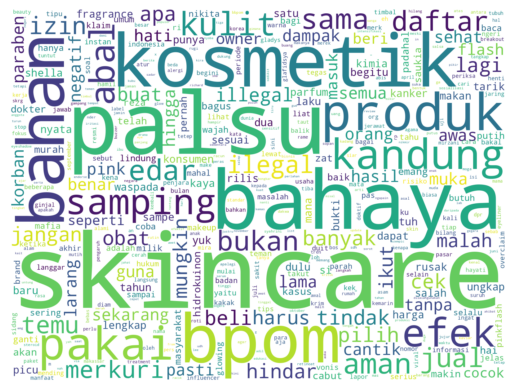

In [ ]:
fig = plt.figure(1)
plt.imshow(Wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()
fig.savefig('datanet5.png', dpi=300)

In [ ]:
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [ ]:
from nltk.sentiment import SentimentIntensityAnalyzer


sia = SentimentIntensityAnalyzer()
def label_sentiment(text):
    score = sia.polarity_scores(text)['compound']
    if score >= 0.05:
        return 'positif'
    elif score <= -0.05:
        return 'negatif'
    else:
        return 'netral'


df['sentimen'] = pd.Series(databersih).apply(label_sentiment)
display(df['sentimen'].value_counts())

,count
sentimen,
netral,459
negatif,72
positif,41


In [ ]:
negatif_sentimen = df[df['sentimen'] == 'negatif']
display(negatif_sentimen[['Text', 'sentimen']])

,Text,sentimen
8,@tanyakanrl skincare memang ga bisa buat teran...,negatif
14,@Barbie_bitchh57 @Garudasmpaimati @whoopziiy P...,negatif
19,nah lho BPOM rilis peringatan skincare dgn bah...,negatif
28,BPOM udah tegas Glafidsya ilegal. Tapi kenapa ...,negatif
29,Label cantik tak selalu aman. Glafidsya ubah d...,negatif
...,...,...
506,gw ga sadar nyokap iri ke gw sampe barusan ban...,negatif
510,@convomf Aneh gak sih liat bukti dia yang foto...,negatif
547,@TukangBedah00 Banyak skincare abal abal berke...,negatif
549,@wihechan Abang banget ini mah bahkan wifi err...,negatif


In [ ]:
df

,Waktu Posting,Text,Tanggal,Bulan,Tahun,sentimen
0,2025-11-16 12:19:15+07:00,enggak usah macem-macem lah kalau enggak paham...,16,11,2025,positif
1,2025-11-12 18:22:51+07:00,Biar gada lagi oknum2 bikin kosmetik skincare ...,12,11,2025,netral
2,2025-11-06 12:59:06+07:00,Slalu update product makeup/skincare dari BPOM...,6,11,2025,netral
3,2025-11-05 12:20:04+07:00,untung deh gw belum beli skincare &amp; make u...,5,11,2025,netral
4,2025-10-28 16:31:58+07:00,Sebelum beli kosmetik pastikan Pilih kosmetik ...,28,10,2025,netral
...,...,...,...,...,...,...
567,2025-11-07 09:29:50+07:00,ya ampun korban pink flash ngeri bgt untung ga...,7,11,2025,netral
568,2025-11-07 08:21:12+07:00,gila banyak bgt korbannya pink flash,7,11,2025,netral
569,2025-11-07 08:08:41+07:00,@strsshdp @ywonnielvs Pink flash lagi di tarik...,7,11,2025,netral
570,2025-11-07 02:29:47+07:00,Pink flash blm BPOM jifrrr fak,7,11,2025,netral


negations itu daftar kata negasi/penyangkalan (misalnya: tidak, bukan, gak, nggak, jangan, tanpa). Fungsinya untuk membalik makna sentimen dari kata yang muncul setelahnya.

Kenapa penting?

Tanpa negasi, kalimat “tidak aman” akan terbaca mengandung kata “aman” (positif) → hasilnya keliru jadi positif.

Dengan negasi, “aman” yang didahului “tidak” dibalik → jadi bernilai negatif.

Contoh efeknya dalam lexicon-based:

“produk ini aman” → skor positif

“produk ini tidak aman” → skor dibalik → jadi negatif

“bukan palsu” → kata “palsu” (negatif) dibalik → jadi lebih positif/netral

Jadi, negations dipakai agar analisis sentimen lebih sesuai konteks bahasa, terutama untuk opini publik yang sering memakai “tidak/ga/nggak”.

/tmp/ipython-input-4159059657.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sentimen', y='Jumlah', data=sentiment_counts, palette='spring')


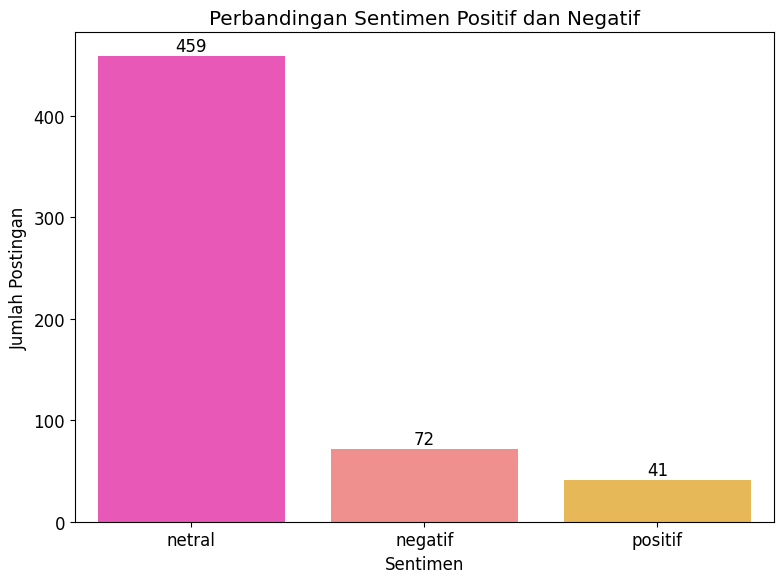

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sentiment_counts = df['sentimen'].value_counts().reset_index()
sentiment_counts.columns = ['Sentimen', 'Jumlah']

plt.figure(figsize=(8, 6))
sns.barplot(x='Sentimen', y='Jumlah', data=sentiment_counts, palette='spring')
plt.title('Perbandingan Sentimen Positif dan Negatif')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Postingan')

for index, row in sentiment_counts.iterrows():
    plt.text(index, row['Jumlah'] + 5, str(row['Jumlah']), color='black', ha='center')

plt.tight_layout()
plt.show()

# WordCloud Positif

In [ ]:
import pandas as pd

encoded = []

for i in range(len(databersih)):
    komentar = databersih[i].strip()
    sentiment_label = df['sentimen'].iloc[i]

    if sentiment_label == 'positif':
        label = 1
    elif sentiment_label == 'negatif':
        label = -1
    else:
        label = 0

    encoded.append((komentar, label))

encode_df = pd.DataFrame(encoded, columns=['komentar', 'label'])
display(encode_df.head())

,komentar,label
0,pakai skincare jaman ortu eyang muda tahan lam...,1
1,lagi oknum buat kosmetik skincare palsu palsu ...,0
2,slalu update produk makeup skincare bpom teman...,0
3,untung beli skincare makeup lagi nyata bahaya ...,0
4,beli kosmetik pasti pilih kosmetik sesuai tipe...,0


In [ ]:
datapos = encode_df[encode_df.label == 1]['komentar']
dataneg = encode_df[encode_df.label == -1]['komentar']
datanet = encode_df[encode_df.label == 0]['komentar']

In [ ]:
dataneg

,komentar
8,skincare memang terang zat kimia bahaya malah ...
14,produk jual dr reza sdh lama stop produksi ket...
19,nah bpom rilis ingat skincare bahan bahaya sal...
28,bpom tegas glafidsya ilegal kenapa banyak beli...
29,label cantik selalu aman glafidsya ubah desain...
...,...
506,sadar nyokap iri sampe barusan i just told her...
510,aneh liat bukti foto wajah maaf korban skincar...
547,banyak skincare palsu palsu liar eh bpom ngapa...
549,abang bahkan wifi error dikit langsung cabut p...


In [ ]:
datapos

,komentar
0,pakai skincare jaman ortu eyang muda tahan lam...
56,dunia sibuk sibuk party saling bungkus pas ham...
62,verlap standar teknis simpan limbah b maya bea...
67,vonis bulan tuntut sopan meski telah laku jaha...
71,beli skincare jangan murah lihat praktis murah...
74,tips aman pilih skincare cek bahan efek sampin...
75,tips aman pilih skincare cek bahan efek sampin...
113,pagi dar ingat eyeshadow trio pinkflash lipsti...
226,detikers kosmetik harus bantu cantik rawat kul...
304,blm bukti cara ilmiah paraben punya efek sampi...


In [ ]:
datanet

,komentar
1,lagi oknum buat kosmetik skincare palsu palsu ...
2,slalu update produk makeup skincare bpom teman...
3,untung beli skincare makeup lagi nyata bahaya ...
4,beli kosmetik pasti pilih kosmetik sesuai tipe...
5,dikatain item sama orang kulit putih merkuri s...
...,...
567,ampun korban pink flash ngeri untung gapernah ...
568,gila banyak korban pink flash
569,pink flash lagi tarik edar kaa tiati yaa
570,pink flash blm bpom jifrrr fak


In [ ]:
satudata=[]
datafinalpos=[]
dfpos=[]

In [ ]:
for line in datapos:
    wo = word_tokenize(line)
    wo = [word for word in wo if not word in stopwords and not word[0].isdigit()]
    datafinalpos.append(wo)
    dfpos.append(" ".join(wo))

In [ ]:
for l in datafinalpos:
    satudata+= l

In [ ]:
datafinalpos={v: satudata.count(v) for v in set(satudata)}

In [ ]:
with open ('datafinalpos_stemming.csv',  'w', newline='', encoding='utf-8') as csv_file:
    writer= csv.writer(csv_file)
    for key, value in datafinalpos.items():
        writer.writerow([key, value])

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vect = TfidfVectorizer(min_df=5, use_idf=True)
X_tfidf = tfidf_vect.fit_transform(dfpos)

print(X_tfidf.shape)

tf = pd.DataFrame(X_tfidf.toarray(), columns=tfidf_vect.get_feature_names_out())
print(tf.shape)


(41, 15)
(41, 15)


In [ ]:
kata = pd.DataFrame.from_dict(datafinalpos,orient='index')
hasilsort1 = kata.sort_values(by=[0], ascending=False)
print(hasilsort1)
pd.DataFrame(hasilsort1).to_csv('hasilsort1.csv', index=True)

             0
skincare    48
palsu       39
pakai       18
abal        11
efek        11
...         ..
abalnyw      1
apakah       1
verifikasi   1
tolong       1
alami        1

[510 rows x 1 columns]


In [ ]:
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

In [ ]:
word_freq_dict = hasilsort1[0].to_dict()

mpl.rcParams['font.size']=12 #10
mpl.rcParams['savefig.dpi']=100 #72
mpl.rcParams['figure.subplot.bottom']=.1

Wordcloud = WordCloud(
    collocations=False,
    background_color='white',
    max_words=10000,
    max_font_size=200,
    min_font_size=5,
    scale=2,
    width=800,
    height=600,
    random_state=43
).generate_from_frequencies(word_freq_dict)

In [ ]:
print(Wordcloud)

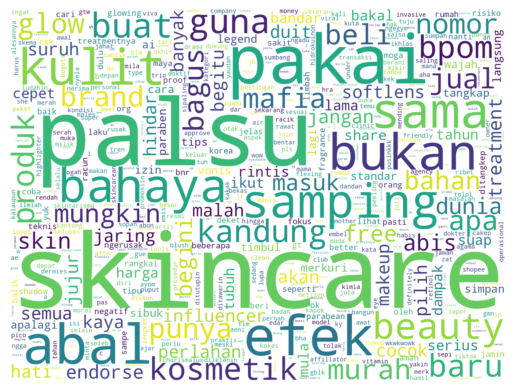

In [ ]:
fig = plt.figure(1)
plt.imshow(Wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()
fig.savefig('datanet5.png', dpi=500)

# negatif

In [ ]:
satudata=[]
datafinalneg=[]
dfneg=[]

In [ ]:
for line in dataneg:
    wo = word_tokenize(line)
    wo = [word for word in wo if not word in stopwords and not word[0].isdigit()]
    datafinalneg.append(wo)
    dfneg.append(" ".join(wo))

In [ ]:
for l in datafinalneg:
    satudata+= l

In [ ]:
datafinalneg={v: satudata.count(v) for v in set(satudata)}

In [ ]:
with open ('datafinalneg_stemming.csv',  'w', newline='', encoding='utf-8') as csv_file:
    writer= csv.writer(csv_file)
    for key, value in datafinalneg.items():
        writer.writerow([key, value])

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vect = TfidfVectorizer(min_df=10, use_idf=True)
X_tfidf = tfidf_vect.fit_transform(dfneg)

print(X_tfidf.shape)

tf = pd.DataFrame(X_tfidf.toarray(), columns=tfidf_vect.get_feature_names_out())
print(tf.shape)

(72, 16)
(72, 16)


In [ ]:
kata = pd.DataFrame.from_dict(datafinalneg,orient='index')
hasilsort2 = kata.sort_values(by=[0], ascending=False)
print(hasilsort2)
pd.DataFrame(hasilsort2).to_csv('hasilsort2.csv', index=True)

           0
skincare  82
bahaya    44
tindak    33
palsu     33
illegal   32
...       ..
deket      1
aware      1
penting    1
jawab      1
artis      1

[539 rows x 1 columns]


In [ ]:
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

In [ ]:
word_freq_dict = hasilsort2[0].to_dict()

#mpl.rcParams['figure.figsize']=(8.0,6.0) #(6.0,4.0)
mpl.rcParams['font.size']=12 #10
mpl.rcParams['savefig.dpi']=100 #72
mpl.rcParams['figure.subplot.bottom']=.1

Wordcloud = WordCloud(
    collocations=False,
    background_color='white',
    max_words=10000,
    max_font_size=200,
    min_font_size=5,
    scale=2,
    width=800,
    height=600,
    random_state=43
).generate_from_frequencies(word_freq_dict)

In [ ]:
print(Wordcloud)

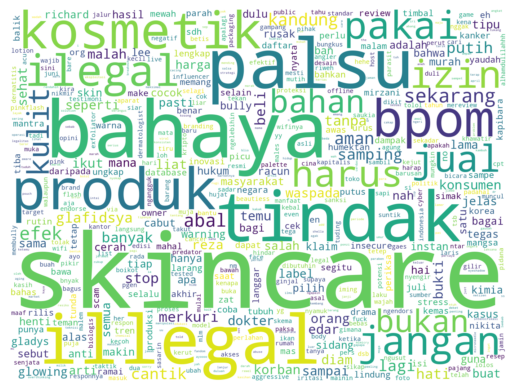

In [ ]:
fig = plt.figure(1)
plt.imshow(Wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()
fig.savefig('datanet5.png', dpi=500)

# netral

In [ ]:
satudata=[]
datafinalnet=[]
dfnet=[]

In [ ]:
for line in datanet:
    wo = word_tokenize(line)
    wo = [word for word in wo if not word in stopwords and not word[0].isdigit()]
    datafinalnet.append(wo)
    dfnet.append(" ".join(wo))

In [ ]:
for l in datafinalnet:
    satudata+= l

In [ ]:
datafinalnet={v: satudata.count(v) for v in set(satudata)}

In [ ]:
with open ('datafinalnet_stemming.csv',  'w', newline='', encoding='utf-8') as csv_file:
    writer= csv.writer(csv_file)
    for key, value in datafinalnet.items():
        writer.writerow([key, value])

In [ ]:
tfidf_vect = TfidfVectorizer(min_df=34, use_idf=True)
X_tfidf = tfidf_vect.fit_transform(dfnet)
print(X_tfidf.shape)

tf = pd.DataFrame(X_tfidf.toarray(), columns=tfidf_vect.get_feature_names_out())
print(tf.shape)

(459, 18)
(459, 18)


In [ ]:
kata = pd.DataFrame.from_dict(datafinalnet,orient='index')
hasilsort3 = kata.sort_values(by=[0], ascending=False)
print(hasilsort3)
pd.DataFrame(hasilsort3).to_csv('hasilsort3.csv', index=True)

                 0
skincare       326
palsu          242
bahaya         227
kosmetik       189
bpom           154
...            ...
tnpa             1
kerap            1
tmk              1
sunsucreennya    1
karir            1

[1926 rows x 1 columns]


In [ ]:
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

In [ ]:
word_freq_dict = hasilsort3[0].to_dict()

#mpl.rcParams['figure.figsize']=(8.0,6.0) #(6.0,4.0)
mpl.rcParams['font.size']=12 #10
mpl.rcParams['savefig.dpi']=100 #72
mpl.rcParams['figure.subplot.bottom']=.1

Wordcloud = WordCloud(
    collocations=False,
    background_color='white',
    max_words=10000,
    max_font_size=200,
    min_font_size=5,
    scale=2,
    width=800,
    height=600,
    random_state=43
).generate_from_frequencies(word_freq_dict)

In [ ]:
print(Wordcloud)

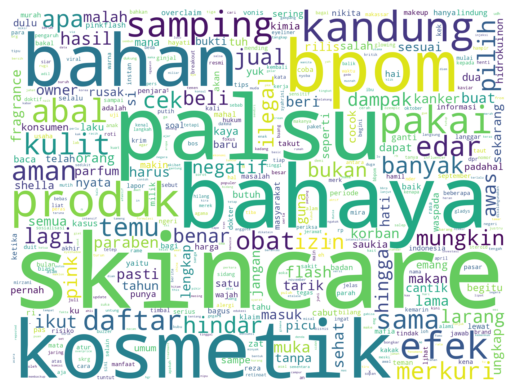

In [ ]:
fig = plt.figure(1)
plt.imshow(Wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()
fig.savefig('datanet5.png', dpi=500)

# modeling

In [ ]:
import pandas as pd

df_label = pd.DataFrame({
    'komentar': databersih,
    'label': df['sentimen']
})

display(df_label.head())

,komentar,label
0,pakai skincare jaman ortu eyang muda tahan lam...,positif
1,lagi oknum buat kosmetik skincare palsu palsu ...,netral
2,slalu update produk makeup skincare bpom teman...,netral
3,untung beli skincare makeup lagi nyata bahaya ...,netral
4,beli kosmetik pasti pilih kosmetik sesuai tipe...,netral


In [ ]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1) Filter & encode label
df_label_filtered = df_label[df_label['label'].isin(['negatif', 'netral', 'positif'])].copy()
df_label_filtered['label'] = df_label_filtered['label'].map({
    'negatif': -1,
    'netral': 0,
    'positif': 1
})

X_text = df_label_filtered['komentar'].fillna('')
y = df_label_filtered['label']

# 2) Model candidates (TF-IDF akan dimasukkan ke Pipeline agar tidak leakage)
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, solver='liblinear', class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, random_state=42, class_weight='balanced'
    )
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {
    name: {'Accuracy': [], 'Precision': [], 'Recall': [], 'F1': []}
    for name in models
}

# 3) Cross-validation (TF-IDF di-fit hanya pada train fold)
for model_name, clf in models.items():
    pipe = Pipeline([
        ('tfidf', TfidfVectorizer(min_df=3, max_df=0.9, ngram_range=(1, 2))),
        ('clf', clf)
    ])

    for train_idx, test_idx in skf.split(X_text, y):
        X_train, X_test = X_text.iloc[train_idx], X_text.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        results[model_name]['Accuracy'].append(accuracy_score(y_test, y_pred))
        results[model_name]['Precision'].append(precision_score(y_test, y_pred, average='weighted', zero_division=0))
        results[model_name]['Recall'].append(recall_score(y_test, y_pred, average='weighted', zero_division=0))
        results[model_name]['F1'].append(f1_score(y_test, y_pred, average='weighted', zero_division=0))

metrics_df = pd.DataFrame({
    'Model': list(models.keys()),
    'Accuracy': [np.mean(results[m]['Accuracy']) for m in models],
    'Precision': [np.mean(results[m]['Precision']) for m in models],
    'Recall': [np.mean(results[m]['Recall']) for m in models],
    'F1-Score': [np.mean(results[m]['F1']) for m in models]
}).round(3)

print(metrics_df)

best_model = metrics_df.loc[metrics_df['F1-Score'].idxmax()]
print("Model terbaik berdasarkan F1-Score:")
print(best_model)

                 Model  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression     0.860      0.839   0.860     0.819
1        Random Forest     0.865      0.853   0.865     0.830
Model terbaik berdasarkan F1-Score:
Model        Random Forest
Accuracy             0.865
Precision            0.853
Recall               0.865
F1-Score              0.83
Name: 1, dtype: object


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

df_label_filtered = df_label[df_label['label'].isin(['negatif', 'netral', 'positif'])].copy()
df_label_filtered['label'] = df_label_filtered['label'].map({
    'negatif': -1,
    'netral': 0,
    'positif': 1
})

X_text = df_label_filtered['komentar'].fillna('')
y = df_label_filtered['label']

tfidf = TfidfVectorizer(
    min_df=3,
    max_df=0.9,
    ngram_range=(1, 2)
)
X = tfidf.fit_transform(X_text)

models = {
    'Logistic Regression (Balanced)': LogisticRegression(
        max_iter=1000,
        solver='liblinear',
        class_weight='balanced'
    ),
    'Random Forest (Balanced)': RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight='balanced'
    )
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {
    model: {
        'Accuracy': [],
        'Precision': [],
        'Recall': [],
        'F1': []
    }
    for model in models
}

for model_name, model in models.items():
    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        results[model_name]['Accuracy'].append(
            accuracy_score(y_test, y_pred)
        )
        results[model_name]['Precision'].append(
            precision_score(y_test, y_pred, average='weighted', zero_division=0)
        )
        results[model_name]['Recall'].append(
            recall_score(y_test, y_pred, average='weighted', zero_division=0)
        )
        results[model_name]['F1'].append(
            f1_score(y_test, y_pred, average='weighted', zero_division=0)
        )

metrics_df = pd.DataFrame({
    'Model': models.keys(),
    'Accuracy': [np.mean(results[m]['Accuracy']) for m in models],
    'Precision': [np.mean(results[m]['Precision']) for m in models],
    'Recall': [np.mean(results[m]['Recall']) for m in models],
    'F1-Score': [np.mean(results[m]['F1']) for m in models]
}).round(3)

print(metrics_df)

best_model = metrics_df.loc[metrics_df['F1-Score'].idxmax()]
print("\nModel terbaik berdasarkan F1-Score:")
print(best_model)


                            Model  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression (Balanced)     0.860      0.839   0.860     0.819
1        Random Forest (Balanced)     0.867      0.858   0.867     0.831

Model terbaik berdasarkan F1-Score:
Model        Random Forest (Balanced)
Accuracy                        0.867
Precision                       0.858
Recall                          0.867
F1-Score                        0.831
Name: 1, dtype: object


In [ ]:
from sklearn.metrics import classification_report
import numpy as np

best_model_name = best_model['Model']
model = models[best_model_name]

y_true_all = []
y_pred_all = []

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, test_idx in skf.split(X, y):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    y_true_all.extend(y_test)
    y_pred_all.extend(y_pred)

print("Classification Report (Out-of-Fold):\n")
print(classification_report(
    y_true_all,
    y_pred_all,
    labels=[-1, 0, 1],
    target_names=['Negatif', 'Netral', 'Positif'],
    digits=3
))

Classification Report (Out-of-Fold):

              precision    recall  f1-score   support

     Negatif      1.000     0.458     0.629        72
      Netral      0.858     1.000     0.924       459
     Positif      1.000     0.098     0.178        41

    accuracy                          0.867       572
   macro avg      0.953     0.519     0.577       572
weighted avg      0.886     0.867     0.833       572



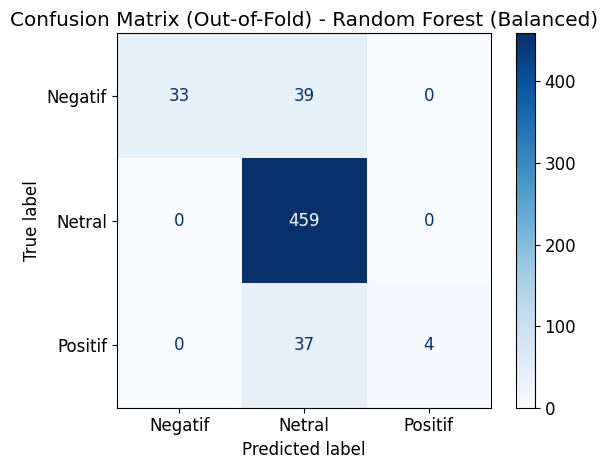

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import numpy as np

best_model_name = best_model['Model']
model = models[best_model_name]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_true_all = []
y_pred_all = []

for train_idx, test_idx in skf.split(X, y):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    y_true_all.extend(y_test)
    y_pred_all.extend(y_pred)

cm = confusion_matrix(
    y_true_all,
    y_pred_all,
    labels=[-1, 0, 1]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Negatif', 'Netral', 'Positif']
)

disp.plot(cmap='Blues', values_format='d')
plt.title(f'Confusion Matrix (Out-of-Fold) - {best_model_name}')
plt.show()